In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import sqlite3
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
model_df = pd.read_pickle("model.pkl")

In [ ]:
model_df.head()

In [6]:
baseline = model_df[(model_df["year"] >= 1992) & (model_df["year"] <= 2000)].copy()

county_cluster_df = (
    baseline.groupby(["STATE", "COUNTY"], as_index=False)
    .agg(
        mean_fire_count=("fire_count", "mean"),
        mean_notable_fire_count=("notable_fire_count", "mean"),
        mean_total_acres=("total_acres", "mean"),
        positive_month_rate=("fire_count", lambda s: (s > 0).mean()),
        notable_month_rate=("target", "mean"),
        mean_max_fire_size=("max_fire_size", "mean")
    )
)


cluster_features = [
    "mean_fire_count", # average number of recorded fires per county-month during baseline
    "mean_notable_fire_count",  # average number of notable fires (>= 300 acres) per county-month during the baseline 
    "mean_total_acres", # average total acres burned per county-month during the baseline
    "positive_month_rate", # proportion of months in the baseline period with at least one recorded fire
    "notable_month_rate", # proportion of months in the baseline period with at least one notable fire.
    "mean_max_fire_size" # average of the monthly maximum fire size within each county
]

X = county_cluster_df[cluster_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
county_cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Frank\anaconda3\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [7]:
model_df = model_df.merge(
    county_cluster_df[["STATE", "COUNTY", "cluster"]],
    on=["STATE", "COUNTY"],
    how="left"
)

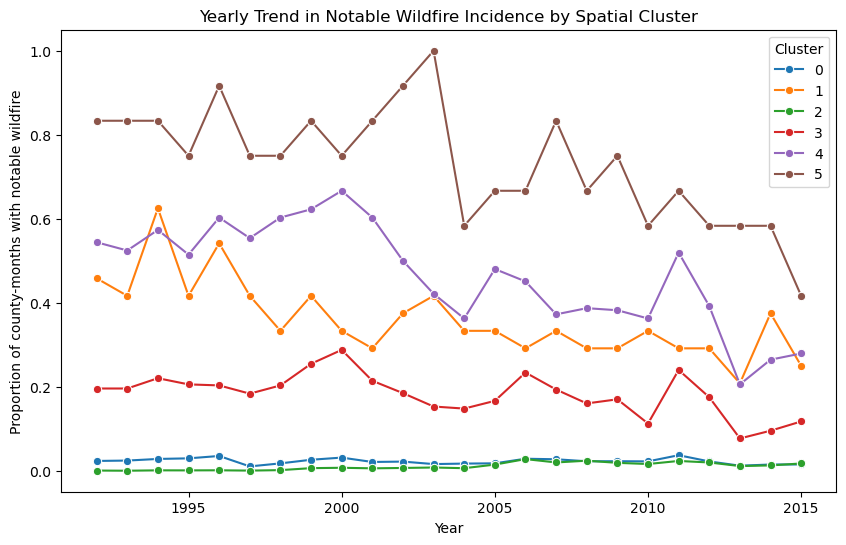

In [22]:

plt.figure(figsize=(10,6))

sns.lineplot(
    data=cluster_year,
    x="year",
    y="target",
    hue="cluster",
    palette="tab10",
    marker="o"
)

plt.title("Yearly Trend in Notable Wildfire Incidence by Spatial Cluster")
plt.xlabel("Year")
plt.ylabel("Proportion of county-months with notable wildfire")
plt.legend(title="Cluster")

plt.show()

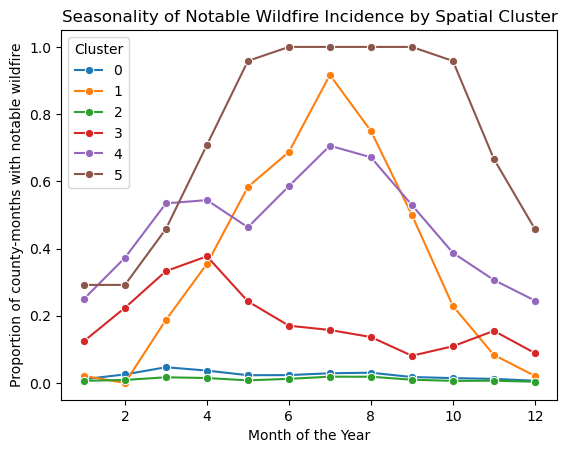

In [18]:
model_df=pd.read_pickle("model_cluster.pkl")
cluster_month = (
    model_df.groupby(["cluster", "month"], as_index=False)["target"]
    .mean()
)

sns.lineplot(
    data=cluster_month,
    x="month",
    y="target",
    hue="cluster",
    palette="tab10",
    marker="o"
)

plt.title("Seasonality of Notable Wildfire Incidence by Spatial Cluster")
plt.xlabel("Month of the Year")
plt.ylabel("Proportion of county-months with notable wildfire")
plt.legend(title="Cluster")

plt.show()

In [ ]:
#Counties were clustered using wildfire summary statistics computed over the baseline period. These features included the average monthly number of fires (mean_fire_count), average monthly number of notable fires (mean_notable_fire_count), average monthly acres burned (mean_total_acres), proportion of months with any fire activity (positive_month_rate), proportion of months with at least one notable fire (notable_month_rate), and the average monthly maximum fire size (mean_max_fire_size). Together, these variables capture wildfire frequency, persistence, and severity, allowing counties with similar historical fire regimes to be grouped into common spatial clusters.

In [19]:
model_df.head()

,STATE,COUNTY,date,year,month,fire_count,notable_fire_count,total_acres,max_fire_size,mean_fire_size,median_fire_size,target,cluster
0,AK,020,1992-01-01,1992,1,0.0,0.0,0.0,0.0,0.0,0.0,0,2
1,AK,020,1992-02-01,1992,2,0.0,0.0,0.0,0.0,0.0,0.0,0,2
2,AK,020,1992-03-01,1992,3,0.0,0.0,0.0,0.0,0.0,0.0,0,2
3,AK,020,1992-04-01,1992,4,0.0,0.0,0.0,0.0,0.0,0.0,0,2
4,AK,020,1992-05-01,1992,5,0.0,0.0,0.0,0.0,0.0,0.0,0,2


In [20]:
df = pd.read_pickle("fire.pkl")
county_coords = (
    df.groupby(["STATE", "COUNTY"], as_index=False)
      .agg(
          LATITUDE=("LATITUDE", "mean"),
          LONGITUDE=("LONGITUDE", "mean")
      )
)

#county_coords.head()

county_cluster_map = (
    model_df[["STATE", "COUNTY", "cluster"]]
    .drop_duplicates()
    .merge(county_coords, on=["STATE", "COUNTY"], how="left")
)

county_cluster_map.head()

,STATE,COUNTY,cluster,LATITUDE,LONGITUDE
0,AK,020,2,60.000833,-149.699444
1,AK,110,2,58.395269,-134.851692
2,AK,122,2,60.502771,-149.603908
3,AK,130,2,55.734028,-131.927951
4,AK,201,2,55.745000,-132.877206


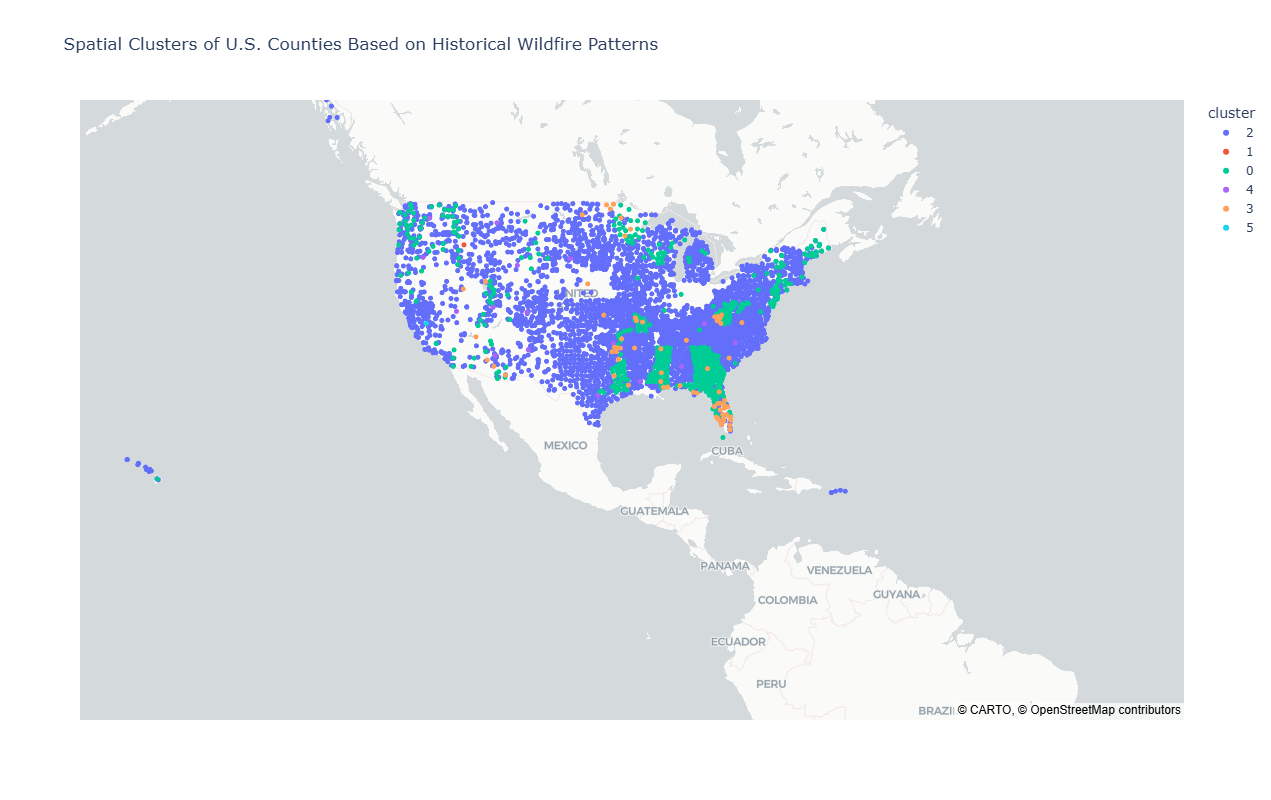

In [29]:
import plotly.express as px
county_cluster_map["cluster"] = county_cluster_map["cluster"].astype(str)
fig = px.scatter_map(
    county_cluster_map,
    lat="LATITUDE",
    lon="LONGITUDE",
    color="cluster",
    hover_data=["STATE", "COUNTY"],
    center=dict(lat=39, lon=-98),
    zoom=3,
    map_style="carto-positron",
    title="Spatial Clusters of U.S. Counties Based on Historical Wildfire Patterns"
)

fig.update_layout(width=1200, height=800)
fig.show()

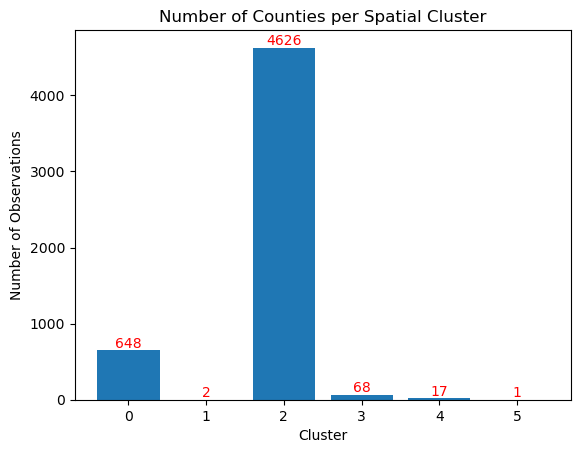

In [16]:
cluster_counts = county_cluster_map["cluster"].value_counts().sort_index()
bars = plt.bar(cluster_counts.index, cluster_counts.values)
for bar in bars:
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    plt.text(x, y, int(y), ha="center", va="bottom", color="red")

plt.xlabel("Cluster")
plt.ylabel("Number of Observations")
plt.title("Number of Counties per Spatial Cluster")

plt.show()

In [17]:
county_cluster_map

,STATE,COUNTY,cluster,LATITUDE,LONGITUDE
0,AK,020,2,60.000833,-149.699444
1,AK,110,2,58.395269,-134.851692
2,AK,122,2,60.502771,-149.603908
3,AK,130,2,55.734028,-131.927951
4,AK,201,2,55.745000,-132.877206
...,...,...,...,...,...
5357,WY,Uinta,2,41.343000,-110.591965
5358,WY,WESTON,2,43.979028,-104.283611
5359,WY,"WESTON, PENNINGTON",2,43.890000,-104.068333
5360,WY,Washakie,0,43.972032,-107.762181


In [13]:
cluster_summary = (
    model_df.groupby("cluster", as_index=False)
    .agg(
        n_counties=("COUNTY", "nunique"),
        target_rate=("target", "mean")
    )
    .sort_values("target_rate")
)
cluster_summary

,cluster,n_counties,target_rate
2,2,2861,0.010736
0,0,516,0.022971
3,3,57,0.183211
1,1,1,0.361111
4,4,1,0.466299
5,5,1,0.732639
